# 5. Figures for the poster

The previous notebooks wrote their results to `../output/*.h5`. This notebook
is a pure **visualisation** layer: it reloads those results and renders a set
of poster-ready figures, saving each to `../output/figures/` as a
high-resolution **PNG** (300 dpi) *and* a vector **PDF**. Because `../output`
is the mounted repository, the files land on your host machine, ready to drop
into a poster.

Run it after notebooks 00–03. It recomputes nothing, so it finishes in seconds.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import matplotlib.pyplot as plt
import firedrake as fd
from firedrake import Function, sqrt

import nivlisen_tutorial as nt

# Poster-quality rendering defaults: larger type, tight bounding box, 300 dpi.
plt.rcParams.update({
    "savefig.dpi": 300, "savefig.bbox": "tight", "figure.dpi": 120,
    "font.size": 13, "axes.titlesize": 15, "axes.titleweight": "bold",
    "axes.labelsize": 12,
})

FIGDIR = "../output/figures"
os.makedirs(FIGDIR, exist_ok=True)

def save(fig, name):
    """Write a figure to ../output/figures as PNG (300 dpi) + vector PDF."""
    for ext in ("png", "pdf"):
        fig.savefig(f"{FIGDIR}/{name}.{ext}")
    print(f"  saved {name}.png / {name}.pdf")

def field(f, ax, **kw):
    """plot_field with the adaptive mesh overlaid as faint transparent triangles."""
    return nt.plot_field(f, ax, show_mesh=True, **kw)

/home/firedrake/firedrake/lib/python3.12/site-packages/pytools/persistent_dict.py:52: RecommendedHashNotFoundWarning: Unable to import recommended hash 'siphash24.siphash13', falling back to 'hashlib.sha256'. Run 'python3 -m pip install siphash24' to install the recommended hash.
  warn("Unable to import recommended hash 'siphash24.siphash13', "


## The model domain and adaptive mesh

The triangulation, refined toward the shear margins, grounding line and fast
trunk from the effective stress and strain rate (notebook 1).

  saved 00_model_domain.png / 00_model_domain.pdf


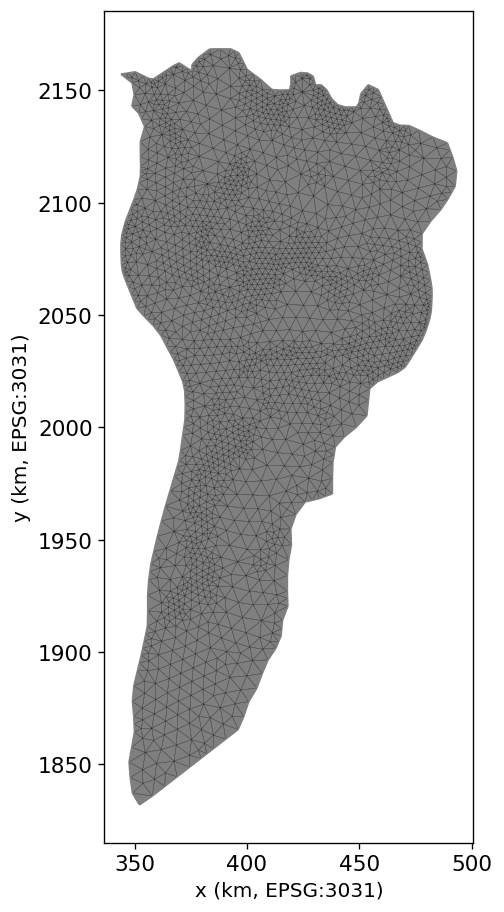

In [2]:
with fd.CheckpointFile("../output/inversion.h5", "r") as chk:
    mesh = chk.load_mesh()
    u_obs = chk.load_function(mesh, "u_obs")
    u_opt = chk.load_function(mesh, "velocity")
    theta = chk.load_function(mesh, "log_friction")
    phi = chk.load_function(mesh, "log_fluidity")

fig, ax = plt.subplots(figsize=(6, 9))
nt.plot_mesh(mesh, ax)
save(fig, "00_model_domain"); plt.show()

## Model skill: observed vs. modelled speed

The inversion (notebook 2) makes the modelled velocity match the observations.
Side by side, on a shared colour scale.

  saved 01_speed_obs_vs_modelled.png / 01_speed_obs_vs_modelled.pdf


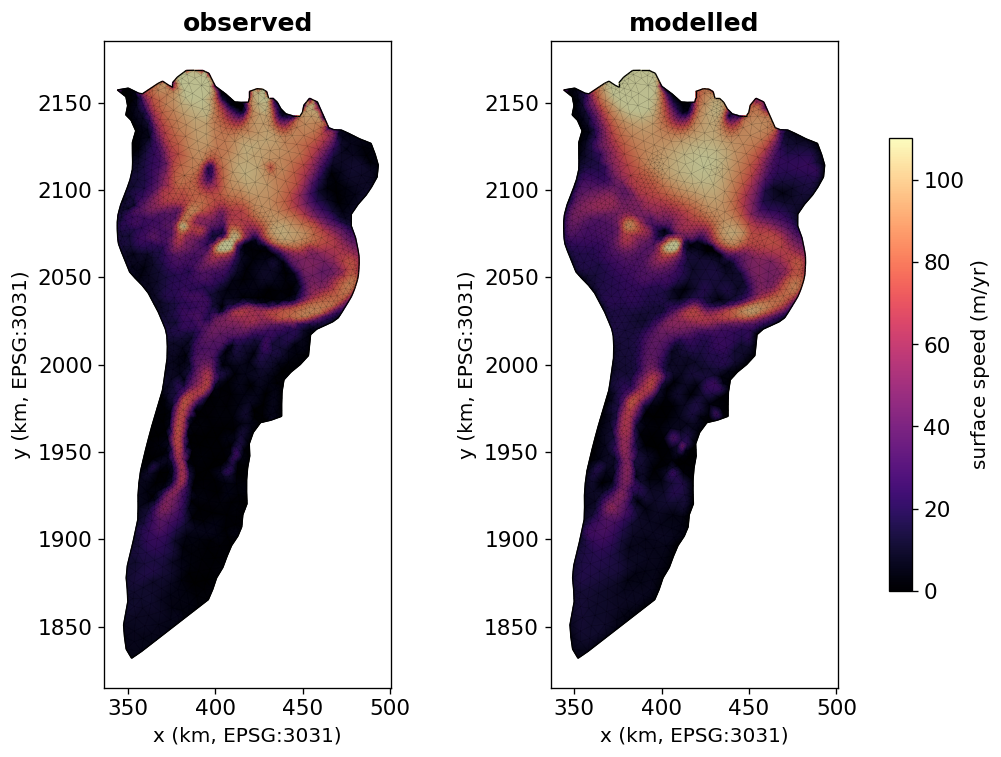

In [3]:
Q = fd.FunctionSpace(mesh, "CG", 1)
speed_obs = Function(Q).interpolate(sqrt(u_obs[0]**2 + u_obs[1]**2))
speed_opt = Function(Q).interpolate(sqrt(u_opt[0]**2 + u_opt[1]**2))
vmax = max(50.0, float(np.percentile(speed_obs.dat.data_ro, 99)))

fig, axes = plt.subplots(1, 2, figsize=(11, 7))
for ax, f, t in [(axes[0], speed_obs, "observed"), (axes[1], speed_opt, "modelled")]:
    c = field(f, ax, vmin=0, vmax=vmax, cmap="magma")
    ax.set_title(t)
fig.colorbar(c, ax=axes, shrink=0.7, label="surface speed (m/yr)")
save(fig, "01_speed_obs_vs_modelled"); plt.show()

## Inferred bed friction and ice fluidity

The two fields the inversion recovers: log-friction θ (stickier bed where
high) on the grounded catchment, and log-fluidity φ (softer ice where high)
across the whole domain.

  saved 02_inferred_friction_fluidity.png / 02_inferred_friction_fluidity.pdf


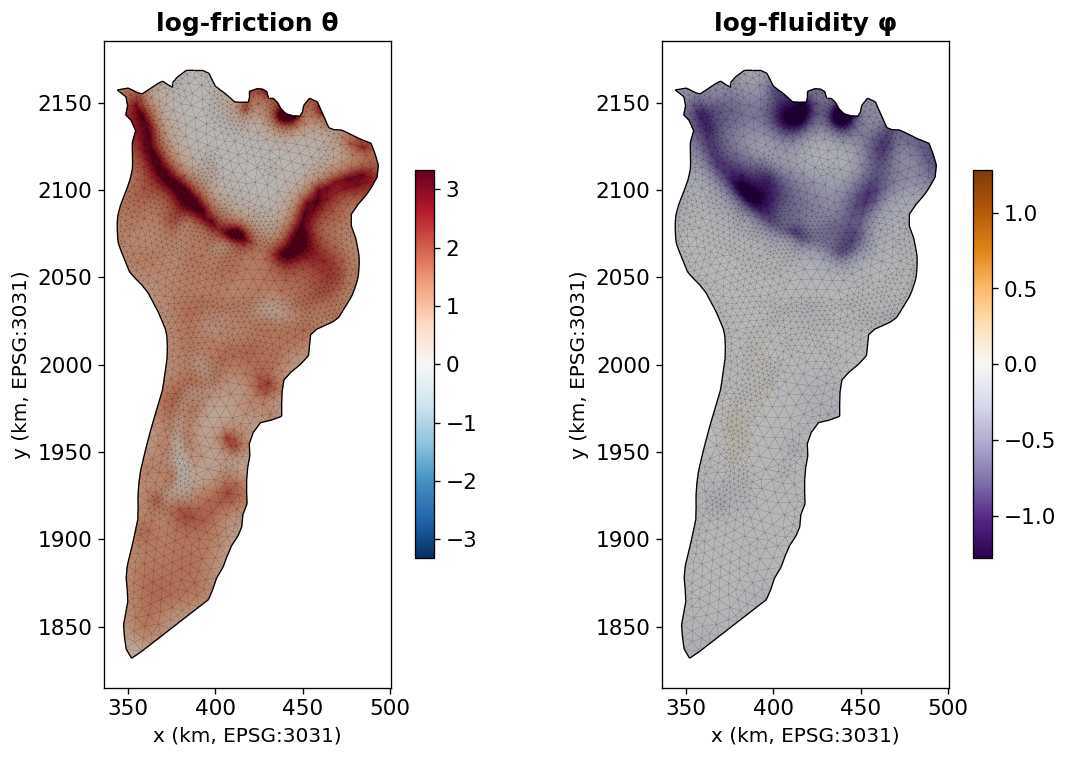

In [4]:
tm = float(np.percentile(np.abs(theta.dat.data_ro), 98)) or 1.0
pm = float(np.percentile(np.abs(phi.dat.data_ro), 98)) or 1.0

fig, axes = plt.subplots(1, 2, figsize=(11, 7))
c0 = field(theta, axes[0], cmap="RdBu_r", vmin=-tm, vmax=tm)
axes[0].set_title("log-friction θ"); fig.colorbar(c0, ax=axes[0], shrink=0.6)
c1 = field(phi, axes[1], cmap="PuOr_r", vmin=-pm, vmax=pm)
axes[1].set_title("log-fluidity φ"); fig.colorbar(c1, ax=axes[1], shrink=0.6)
save(fig, "02_inferred_friction_fluidity"); plt.show()

## Where the data constrain the inversion

The posterior uncertainty reduction (notebook 3): near 1 where the velocity
pins the controls down, near 0 where we lean on the prior.

  saved 03_uncertainty_reduction.png / 03_uncertainty_reduction.pdf


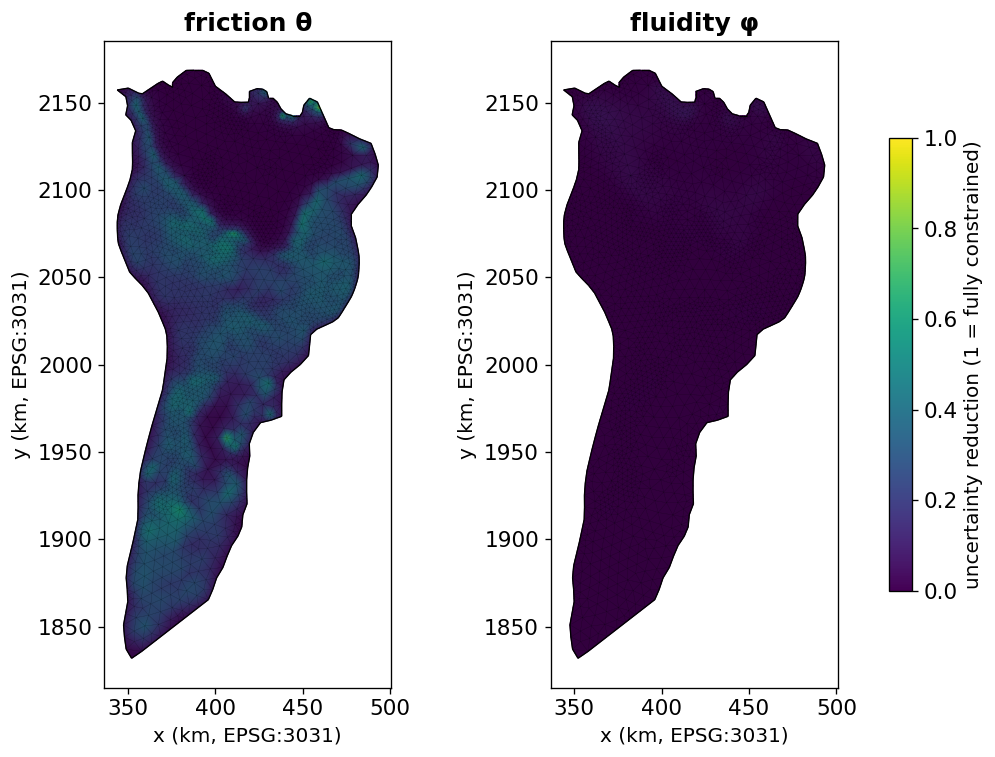

In [5]:
with fd.CheckpointFile("../output/uncertainty.h5", "r") as chk:
    mesh_u = chk.load_mesh()
    red_theta = chk.load_function(mesh_u, "reduction_theta")
    red_phi = chk.load_function(mesh_u, "reduction_phi")

fig, axes = plt.subplots(1, 2, figsize=(11, 7))
for ax, f, t in [(axes[0], red_theta, "friction θ"), (axes[1], red_phi, "fluidity φ")]:
    c = field(f, ax, vmin=0, vmax=1, cmap="viridis")
    ax.set_title(t)
fig.colorbar(c, ax=axes, shrink=0.7, label="uncertainty reduction (1 = fully constrained)")
save(fig, "03_uncertainty_reduction"); plt.show()

## Grounding-zone flux sensitivity to melt (the headline)

From notebook 4: first the adjoint sensitivity of the discharge to thinning,
then the melt-sensitivity map — routed (Fill–Spill–Merge) vs. thinning in
place — the figure the poster is built around.

  saved 04_thinning_sensitivity.png / 04_thinning_sensitivity.pdf


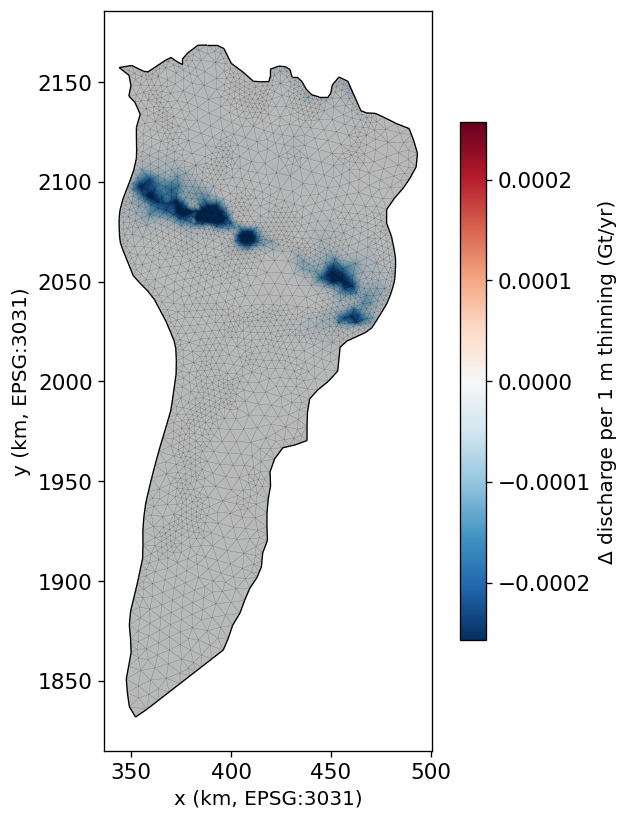

In [6]:
with fd.CheckpointFile("../output/melt_sensitivity.h5", "r") as chk:
    mesh_m = chk.load_mesh()
    dD = chk.load_function(mesh_m, "dD_thinning")
    s_routed = chk.load_function(mesh_m, "sens_routed")
    s_unrouted = chk.load_function(mesh_m, "sens_unrouted")

fig, ax = plt.subplots(figsize=(6, 8))
m = float(np.percentile(np.abs(dD.dat.data_ro), 99)) or 1.0
c = field(dD, ax, cmap="RdBu_r", vmin=-m, vmax=m)
fig.colorbar(c, ax=ax, shrink=0.7, label="Δ discharge per 1 m thinning (Gt/yr)")
save(fig, "04_thinning_sensitivity"); plt.show()

  saved 05_melt_sensitivity_routed_vs_unrouted.png / 05_melt_sensitivity_routed_vs_unrouted.pdf


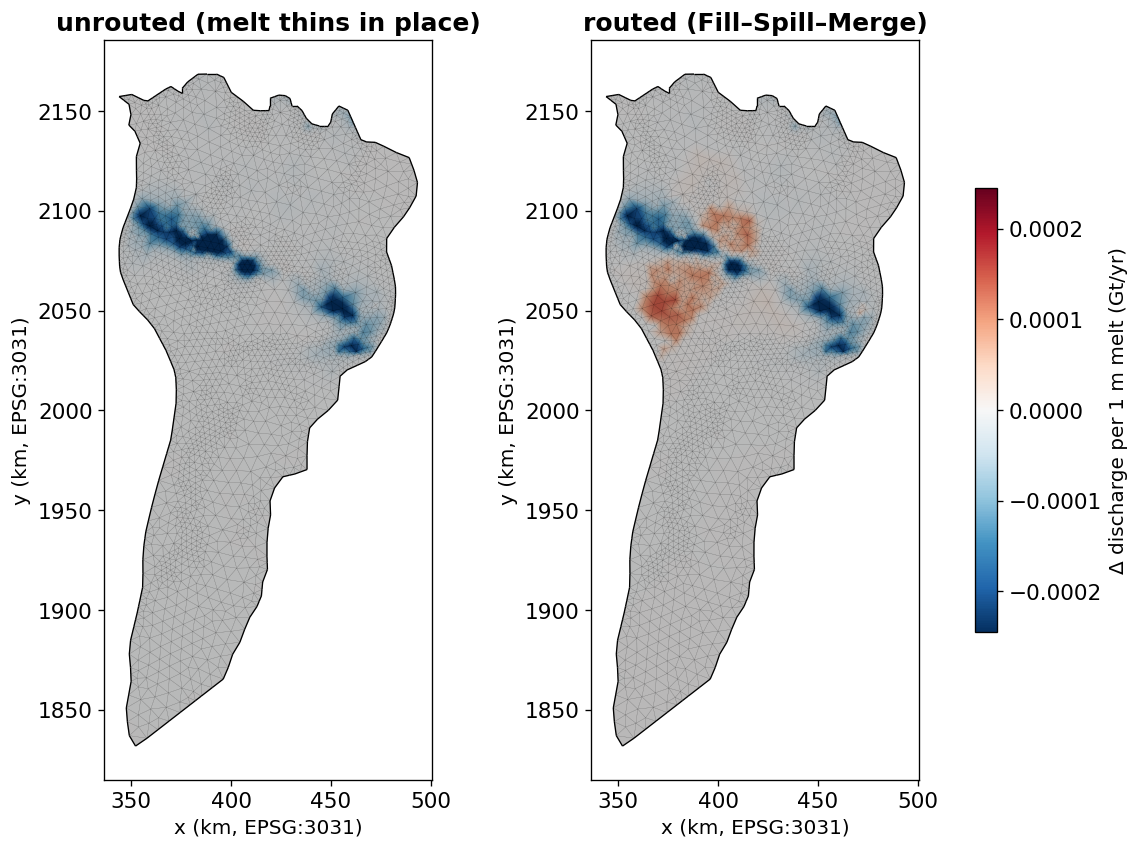

In [7]:
both = np.concatenate([s_routed.dat.data_ro, s_unrouted.dat.data_ro])
m = float(np.percentile(np.abs(both), 99)) or 1.0
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
for ax, f, t in [(axes[0], s_unrouted, "unrouted (melt thins in place)"),
                 (axes[1], s_routed, "routed (Fill–Spill–Merge)")]:
    c = field(f, ax, cmap="RdBu_r", vmin=-m, vmax=m)
    ax.set_title(t)
fig.colorbar(c, ax=axes, shrink=0.6, label="Δ discharge per 1 m melt (Gt/yr)")
save(fig, "05_melt_sensitivity_routed_vs_unrouted"); plt.show()

## The saved figures

Everything above is now on the host under `output/figures/` in both formats.

In [8]:
print("figures written to ../output/figures/:")
for f in sorted(os.listdir(FIGDIR)):
    print("  ", f, f"({os.path.getsize(f'{FIGDIR}/{f}')/1e3:.0f} kB)")

figures written to ../output/figures/:


   00_model_domain.pdf (72 kB)
   00_model_domain.png (1004 kB)
   01_speed_obs_vs_modelled.pdf (430 kB)
   01_speed_obs_vs_modelled.png (1787 kB)
   02_inferred_friction_fluidity.pdf (420 kB)
   02_inferred_friction_fluidity.png (1901 kB)
   03_uncertainty_reduction.pdf (415 kB)
   03_uncertainty_reduction.png (1463 kB)
   04_thinning_sensitivity.pdf (211 kB)
   04_thinning_sensitivity.png (1033 kB)
   05_melt_sensitivity_routed_vs_unrouted.pdf (416 kB)
   05_melt_sensitivity_routed_vs_unrouted.png (2031 kB)
